In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import f1_score, make_scorer
from sklearn.model_selection import GridSearchCV
from sklearn.semi_supervised import LabelPropagation, LabelSpreading, SelfTrainingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import optuna
from sklearn.impute import SimpleImputer

/Users/pritibhunia/repos/medium-voltage-cable/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
filePath = "/Users/pritibhunia/repos/medium-voltage-cable/Real Data/PD_complete.csv"
data = pd.read_csv(filePath, delimiter=';')
data.dropna(inplace=True)
print(data.head())


   cable_id  meas_id  plan_id  pd_id  line_nr  nr_voltage_steps  pd_nr  \
0         1        1        1      1        1                 2      1   
1         2        2        4      4        1                 2      1   
2         2        2        4      4        1                 2      4   
3         2        2        4      4        1                 2      2   
4         2        2        4      4        1                 2      3   

   pd_distance_m  max_pd_pc  voltage_step_factor pd_cable_or_connection_type  \
0           5063      850.0                  1.8                   VPE-Kabel   
1              5      620.0                  1.7          Papier-Masse-Kabel   
2            212      820.0                  1.7          Papier-Masse-Kabel   
3             55      580.0                  1.7          Papier-Masse-Kabel   
4            143      520.0                  1.7          Papier-Masse-Kabel   

      pd_distribution pd_assessment_category    cable_type  
0            

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376 entries, 0 to 375
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cable_id                     376 non-null    int64  
 1   meas_id                      376 non-null    int64  
 2   plan_id                      376 non-null    int64  
 3   pd_id                        376 non-null    int64  
 4   line_nr                      376 non-null    int64  
 5   nr_voltage_steps             376 non-null    int64  
 6   pd_nr                        376 non-null    int64  
 7   pd_distance_m                376 non-null    int64  
 8   max_pd_pc                    376 non-null    float64
 9   voltage_step_factor          376 non-null    float64
 10  pd_cable_or_connection_type  376 non-null    object 
 11  pd_distribution              376 non-null    object 
 12  pd_assessment_category       376 non-null    object 
 13  cable_type          

In [4]:
data

,cable_id,meas_id,plan_id,pd_id,line_nr,nr_voltage_steps,pd_nr,pd_distance_m,max_pd_pc,voltage_step_factor,pd_cable_or_connection_type,pd_distribution,pd_assessment_category,cable_type
0,1,1,1,1,1,2,1,5063,850.0,1.8,VPE-Kabel,Linie,4,XLPE
1,2,2,4,4,1,2,1,5,620.0,1.7,Papier-Masse-Kabel,Glocke symmetrisch,1,Papier-Masse
2,2,2,4,4,1,2,4,212,820.0,1.7,Papier-Masse-Kabel,Glocke symmetrisch,1,Papier-Masse
3,2,2,4,4,1,2,2,55,580.0,1.7,Papier-Masse-Kabel,Bar,1,Papier-Masse
4,2,2,4,4,1,2,3,143,520.0,1.7,Papier-Masse-Kabel,Bar,1,Papier-Masse
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,169,206,511,260,2,8,5,185,2325.3,1.7,Übergangsmuffe Papier-Masse auf Papier-Masse,Glocke symmetrisch,1,Mischkabel
372,169,206,511,261,3,8,5,185,2531.3,1.7,Übergangsmuffe Papier-Masse auf Papier-Masse,Glocke symmetrisch,1,Mischkabel
373,170,207,514,262,1,8,6,350,2180.7,1.7,Papier-Masse-Kabel,Bar,1,Papier-Masse
374,170,207,514,263,2,8,3,220,3010.5,1.7,Übergangsmuffe Papier-Masse auf Papier-Masse,Bar,1,Papier-Masse


In [5]:
target_column = 'pd_assessment_category'

In [6]:
data.isnull().sum()

cable_id                       0
meas_id                        0
plan_id                        0
pd_id                          0
line_nr                        0
nr_voltage_steps               0
pd_nr                          0
pd_distance_m                  0
max_pd_pc                      0
voltage_step_factor            0
pd_cable_or_connection_type    0
pd_distribution                0
pd_assessment_category         0
cable_type                     0
dtype: int64

#### Drop rows when pd_assessment_category is Missing connection types

In [7]:
data = data[data['pd_assessment_category'] != 'Missing connection types']
data = data[data['pd_cable_or_connection_type']!='Übergangsmuffe XLPE auf Papier-Masse']

In [8]:
# Covert to numeric
data[target_column] = pd.to_numeric(data[target_column], errors='coerce')

In [9]:
# find out columns of object dtypes
object_cols = data.select_dtypes(include=["object"]).columns
# get distinct values
for col in object_cols:
    print(f"Distinct values in '{col}' column:")
    print(data[col].unique())
    print("-" * 30)

Distinct values in 'pd_cable_or_connection_type' column:
['VPE-Kabel' 'Papier-Masse-Kabel' 'Übergangsmuffe Papier-Masse auf (V)PE'
 'Übergangsmuffe (V)PE auf Papier-Masse' 'Endverschluss'
 'Übergangsmuffe Papier-Masse auf Papier-Masse']
------------------------------
Distinct values in 'pd_distribution' column:
['Linie' 'Glocke symmetrisch' 'Bar' 'Glocke links' 'Glocke rechts']
------------------------------
Distinct values in 'cable_type' column:
['XLPE' 'Papier-Masse' 'Mischkabel']
------------------------------


In [10]:
enc = LabelEncoder()
for col in object_cols:
    data[col] = enc.fit_transform(data[col])

In [11]:
for col in object_cols:
    print(f"Distinct values in '{col}' column:")
    print(data[col].unique())
    print("-" * 30)

Distinct values in 'pd_cable_or_connection_type' column:
[2 1 4 3 0 5]
------------------------------
Distinct values in 'pd_distribution' column:
[4 3 0 1 2]
------------------------------
Distinct values in 'cable_type' column:
[2 1 0]
------------------------------


                              line_nr  nr_voltage_steps     pd_nr  \
line_nr                      1.000000         -0.040713 -0.031883   
nr_voltage_steps            -0.040713          1.000000  0.212611   
pd_nr                       -0.031883          0.212611  1.000000   
pd_distance_m               -0.038485         -0.287546  0.135080   
max_pd_pc                    0.050225         -0.228531 -0.162202   
voltage_step_factor         -0.096658          0.552889  0.020080   
pd_cable_or_connection_type -0.005508          0.122308 -0.066390   
pd_distribution             -0.019229          0.221162 -0.128063   
pd_assessment_category      -0.060055         -0.011970 -0.119509   
cable_type                  -0.025595          0.277676  0.231345   

                             pd_distance_m  max_pd_pc  voltage_step_factor  \
line_nr                          -0.038485   0.050225            -0.096658   
nr_voltage_steps                 -0.287546  -0.228531             0.552889   
pd_nr 

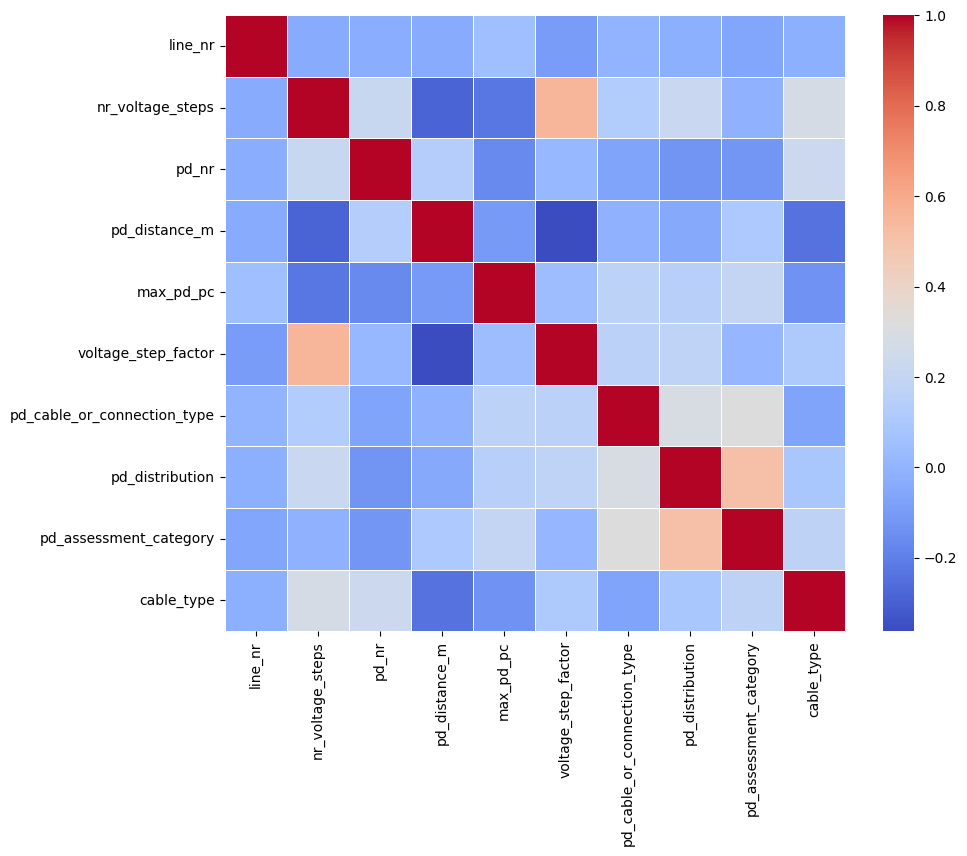

In [12]:
data_for_analysis = data.drop(['cable_id', 'plan_id', 'pd_id', 'meas_id'], axis=1)
correlation_matrix = data_for_analysis.corr()
print(correlation_matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.show()

In [13]:
data_for_analysis

,line_nr,nr_voltage_steps,pd_nr,pd_distance_m,max_pd_pc,voltage_step_factor,pd_cable_or_connection_type,pd_distribution,pd_assessment_category,cable_type
0,1,2,1,5063,850.0,1.8,2,4,4,2
1,1,2,1,5,620.0,1.7,1,3,1,1
2,1,2,4,212,820.0,1.7,1,3,1,1
3,1,2,2,55,580.0,1.7,1,0,1,1
4,1,2,3,143,520.0,1.7,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...
371,2,8,5,185,2325.3,1.7,5,3,1,0
372,3,8,5,185,2531.3,1.7,5,3,1,0
373,1,8,6,350,2180.7,1.7,1,0,1,1
374,2,8,3,220,3010.5,1.7,5,0,1,1


In [14]:
data_for_analysis = data_for_analysis[(data_for_analysis['max_pd_pc'] != 43000) & (data_for_analysis['max_pd_pc'] != 46000)]
data_for_analysis = data_for_analysis[data_for_analysis['pd_distance_m'] != 5063]

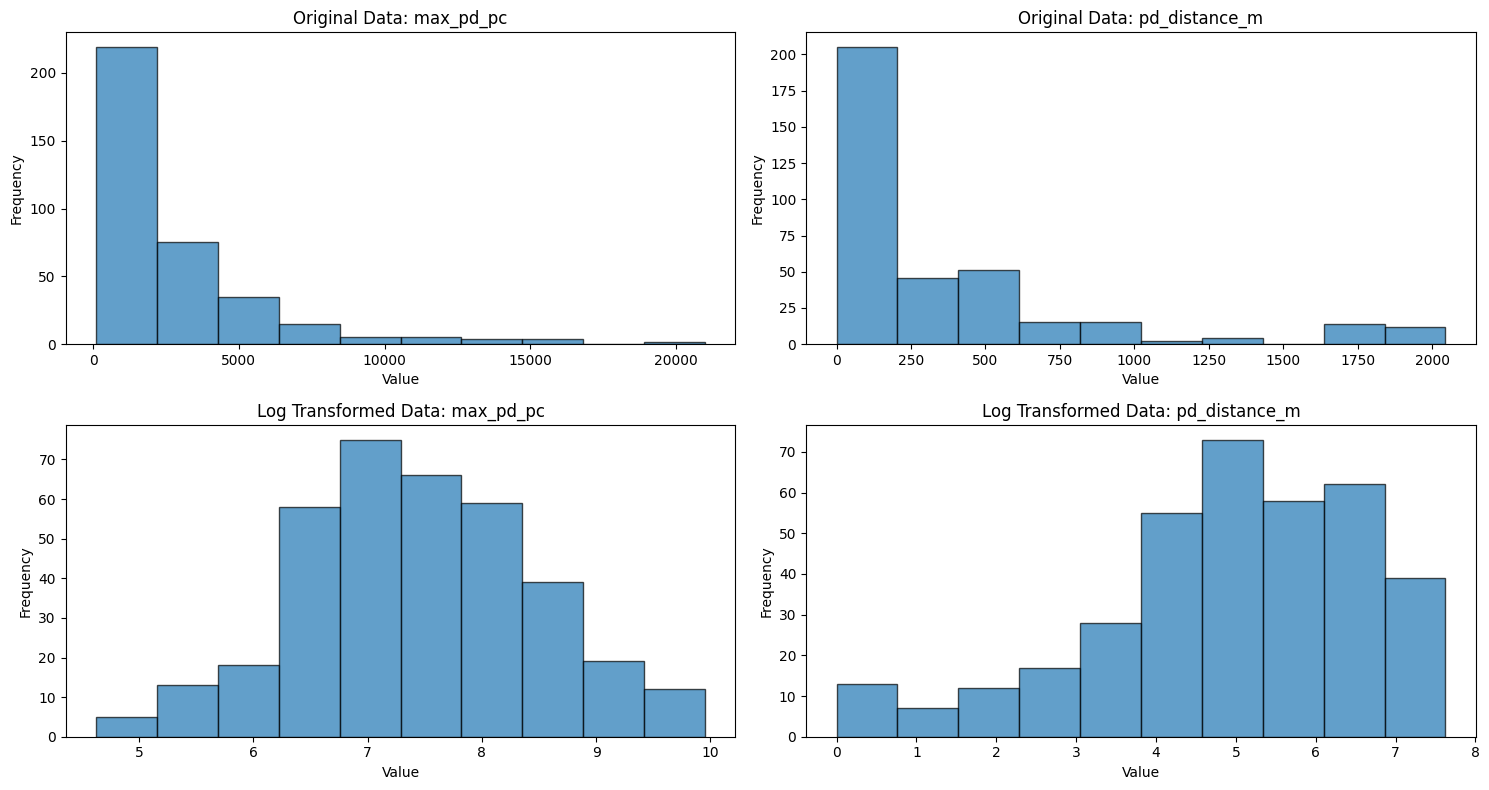

In [15]:
# Manually specify the numerical features
numerical_features = ['max_pd_pc', 'pd_distance_m']  # List of numerical columns to include
selected_data = data_for_analysis[numerical_features]

# Apply log transformation (add 1 to avoid log(0) issues)
log_transformed = selected_data.apply(lambda x: np.log1p(x))

# Plotting
fig, axes = plt.subplots(2, len(selected_data.columns), figsize=(15, 8))

# Titles for each transformation
titles = ["Original Data", "Log Transformed Data"]

# Loop through features and transformations
for i, col in enumerate(selected_data.columns):
    # Original Data
    axes[0, i].hist(selected_data[col], bins=10, edgecolor='k', alpha=0.7)
    axes[0, i].set_title(f"{titles[0]}: {col}")
    axes[0, i].set_xlabel("Value")
    axes[0, i].set_ylabel("Frequency")
    
    # Log Transformed Data
    axes[1, i].hist(log_transformed[col], bins=10, edgecolor='k', alpha=0.7)
    axes[1, i].set_title(f"{titles[1]}: {col}")
    axes[1, i].set_xlabel("Value")
    axes[1, i].set_ylabel("Frequency")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [16]:
data_for_analysis[numerical_features] = log_transformed

In [17]:
# Get input/output dataframes
y = data_for_analysis[target_column]
x = data_for_analysis.drop([target_column],axis=1)

In [18]:
# Standard deviation before scaling
x.std()

line_nr                        0.814994
nr_voltage_steps               3.013265
pd_nr                          1.484119
pd_distance_m                  1.693108
max_pd_pc                      1.004874
voltage_step_factor            0.233733
pd_cable_or_connection_type    0.990323
pd_distribution                1.541608
cable_type                     0.660661
dtype: float64

In [19]:
# apply scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(x)
x_standardized = pd.DataFrame(scaled_features, columns=x.columns)

In [20]:
# standard deviation after scaling
x_standardized.std()

line_nr                        1.001376
nr_voltage_steps               1.001376
pd_nr                          1.001376
pd_distance_m                  1.001376
max_pd_pc                      1.001376
voltage_step_factor            1.001376
pd_cable_or_connection_type    1.001376
pd_distribution                1.001376
cable_type                     1.001376
dtype: float64

In [21]:
x_standardized.columns

Index(['line_nr', 'nr_voltage_steps', 'pd_nr', 'pd_distance_m', 'max_pd_pc',
       'voltage_step_factor', 'pd_cable_or_connection_type', 'pd_distribution',
       'cable_type'],
      dtype='object')

#### Semi-Supervised Learning


In [22]:
# Convert target to semi-supervised format (-1 for unlabeled data)
def create_semi_supervised_labels(y, label_percentage):
    np.random.seed(30)
    labeled_indices = np.random.choice(len(y), size=int(len(y) * label_percentage), replace=False)
    y_semi = np.full_like(y, fill_value=-1, dtype=int)
    y_semi[labeled_indices] = y[labeled_indices]
    return y_semi

### Let's do a grid search for both models with weighted F1-score

In [23]:
def run_grid_search(X, y, model_type):
    model = LabelPropagation() if model_type == 'LabelPropagation' else LabelSpreading()

    param_grid = {
        'kernel': ['rbf', 'knn'],
        'gamma': [10, 20, 50, 100, 150]
    }

    if model_type == 'LabelSpreading':  # Only LabelSpreading supports `alpha`
        param_grid['alpha'] = [0.1, 0.3, 0.5, 0.8]

    # Let's define scoring metrics for grid search
    scoring = {'accuracy': 'accuracy', 'f1_weighted': make_scorer(f1_score, average='weighted', zero_division=0)}

    grid = GridSearchCV(model, param_grid, scoring=scoring, refit='accuracy', cv=3, n_jobs=-1)

    # Filter out unlabeled data points
    labeled_indices = y != -1
    X_labeled, y_labeled = X[labeled_indices], y[labeled_indices]

    grid.fit(X_labeled, y_labeled)

    # Now save the best estimator and parameters
    best_model = grid.best_estimator_
    best_params = grid.best_params_
    best_accuracy = grid.best_score_

    return best_params, best_accuracy, best_model

##### Using Optuna

In [24]:
def run_optuna_optimization(X, y, model_type, n_trials=20):
    # Filter labeled data
    labeled_indices = y != -1
    X_labeled, y_labeled = X[labeled_indices], y[labeled_indices]

    def objective(trial):
        if model_type in ['LabelPropagation', 'LabelSpreading']:
            kernel = trial.suggest_categorical('kernel', ['rbf', 'knn'])
            gamma = trial.suggest_categorical('gamma', [10, 20, 50, 100])
            if model_type == 'LabelPropagation':
                model = LabelPropagation(kernel=kernel, gamma=gamma)
            else:
                alpha = trial.suggest_categorical('alpha', [0.1, 0.3, 0.5, 0.8])
                model = LabelSpreading(kernel=kernel, gamma=gamma, alpha=alpha)
        else:  # Self-Training: using default SVC as base estimator
            base_estimator = SVC(probability=True, gamma='scale')
            model = SelfTrainingClassifier(base_estimator)

        # Evaluate using 3-fold cross-validation on the labeled data
        scores = cross_val_score(model, X_labeled, y_labeled, cv=3, scoring='accuracy', n_jobs=-1)
        return scores.mean()

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)
    best_params = study.best_trial.params
    best_score = study.best_value

    # Build the best model using the best parameters.
    if model_type in ['LabelPropagation', 'LabelSpreading']:
        if model_type == 'LabelPropagation':
            best_model = LabelPropagation(**best_params)
        else:
            best_model = LabelSpreading(**best_params)
    else:
        best_model = SelfTrainingClassifier(SVC(probability=True, gamma='scale'))

    # Train the best model on the full labeled data.
    best_model.fit(X_labeled, y_labeled)
    return best_params, best_score, best_model

### Progressive Validation 

labeled_percentages = [0.1, 0.2, 0.4, 0.6, 0.8]
results = []

for perc in labeled_percentages:
    y_semi = create_semi_supervised_labels(y.to_numpy(), perc)

    for model_type in ['LabelPropagation', 'LabelSpreading']:
        best_params, best_accuracy, best_model = run_grid_search(x_standardized.to_numpy(), y_semi, model_type)

        # Predict on the entire dataset (both labeled and unlabeled data)
        y_pred = best_model.predict(x_standardized.to_numpy())  # Predict all data points

        # Separate labeled and unlabeled data points
        labeled_indices = y_semi != -1
        y_true = y.to_numpy()  # True values (including labeled and unlabeled)
        
        # Calculate the weighted F1-score on the labeled data only (to compare against true labels)
        weighted_f1 = f1_score(y_true[labeled_indices], y_pred[labeled_indices], average='weighted', zero_division=0)

        results.append({
            'Model': model_type, 
            'Labeled %': perc, 
            'Best Params': best_params, 
            'Best Accuracy': best_accuracy,
            'Weighted F1 Score': weighted_f1
        })

# Convert results to DataFrame to display
results_df = pd.DataFrame(results)
print("Labeled Data Requirement Results:\n", results_df)

In [25]:
labeled_percentages = [0.1, 0.2, 0.4, 0.6, 0.8]
results = []

for perc in labeled_percentages:
    y_semi = create_semi_supervised_labels(y.to_numpy(), perc)
    
    for model_type in ['LabelPropagation', 'LabelSpreading', 'Self-Training']:
        best_params, best_accuracy, best_model = run_optuna_optimization(x_standardized.to_numpy(), y_semi, model_type, n_trials=20)
        
        # Predict on the entire dataset (both labeled and unlabeled data)
        y_pred = best_model.predict(x_standardized.to_numpy())
        
        # Only evaluate metrics on the originally labeled data
        labeled_indices = y_semi != -1
        y_true = y.to_numpy()
        weighted_f1 = f1_score(y_true[labeled_indices], y_pred[labeled_indices], average='weighted', zero_division=0)
        
        results.append({
            'Model': model_type,
            'Labeled %': perc,
            'Best Params': best_params,
            'Best Accuracy': best_accuracy,
            'Weighted F1 Score': weighted_f1
        })

# Convert results to DataFrame and display
results_df = pd.DataFrame(results)
print("Labeled Data Requirement Results:\n", results_df)

[I 2025-02-17 15:19:59,281] A new study created in memory with name: no-name-c8ae3319-a7d3-45a0-a871-e52f2ef1773b
/Users/pritibhunia/repos/medium-voltage-cable/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
[I 2025-02-17 15:20:02,202] Trial 0 finished with value: 0.6111111111111112 and parameters: {'kernel': 'rbf', 'gamma': 10}. Best is trial 0 with value: 0.6111111111111112.
/Users/pritibhunia/repos/medium-voltage-cable/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
/Users/pritibhunia/repos/medium-voltage-cable/.venv/lib/python3.12/site-packages/sklearn/semi_supervised/_label_propagation.py:230: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer
/Users/pritibhunia/repos/medium-volt

Labeled Data Requirement Results:
                Model  Labeled %  \
0   LabelPropagation        0.1   
1     LabelSpreading        0.1   
2      Self-Training        0.1   
3   LabelPropagation        0.2   
4     LabelSpreading        0.2   
5      Self-Training        0.2   
6   LabelPropagation        0.4   
7     LabelSpreading        0.4   
8      Self-Training        0.4   
9   LabelPropagation        0.6   
10    LabelSpreading        0.6   
11     Self-Training        0.6   
12  LabelPropagation        0.8   
13    LabelSpreading        0.8   
14     Self-Training        0.8   

                                      Best Params  Best Accuracy  \
0                 {'kernel': 'rbf', 'gamma': 100}       0.583333   
1   {'kernel': 'rbf', 'gamma': 100, 'alpha': 0.8}       0.555556   
2                                              {}       0.666667   
3                 {'kernel': 'knn', 'gamma': 100}       0.569444   
4    {'kernel': 'knn', 'gamma': 50, 'alpha': 0.3}       0.527778

#### Let's plot now

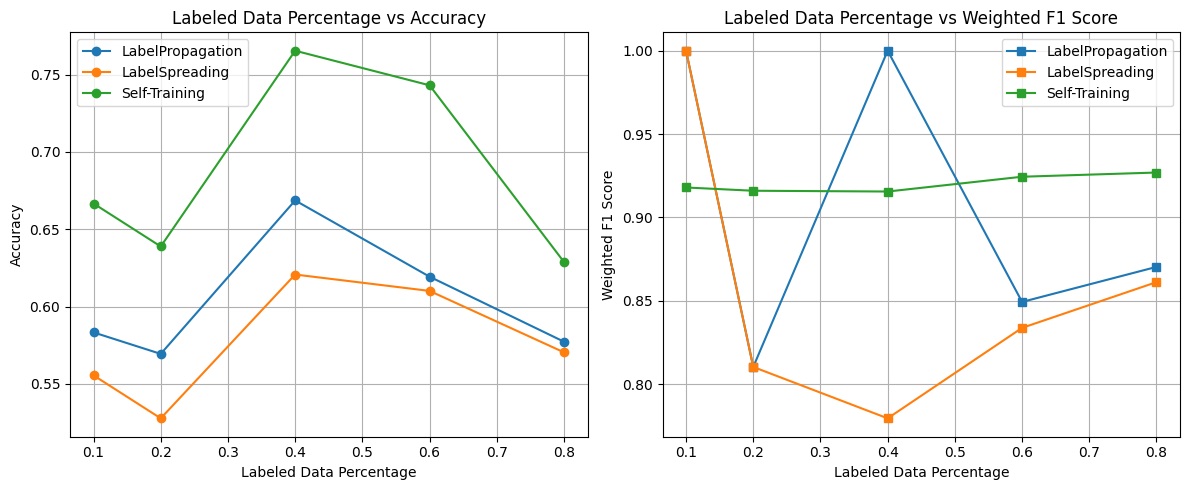

In [26]:
plt.figure(figsize=(12, 5))

# Subplot 1: Accuracy vs Labeled Percentage
plt.subplot(1, 2, 1)
for model_type in ['LabelPropagation', 'LabelSpreading', 'Self-Training']:
    subset = results_df[results_df['Model'] == model_type]
    plt.plot(subset['Labeled %'], subset['Best Accuracy'], marker='o', label=f"{model_type}")

plt.title('Labeled Data Percentage vs Accuracy')
plt.xlabel('Labeled Data Percentage')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# Subplot 2: Weighted F1 Score vs Labeled Percentage
plt.subplot(1, 2, 2)
for model_type in ['LabelPropagation', 'LabelSpreading', 'Self-Training']:
    subset = results_df[results_df['Model'] == model_type]
    plt.plot(subset['Labeled %'], subset['Weighted F1 Score'], marker='s', label=f"{model_type}")

plt.title('Labeled Data Percentage vs Weighted F1 Score')
plt.xlabel('Labeled Data Percentage')
plt.ylabel('Weighted F1 Score')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

### Missing Data

In [27]:
def add_missing_data(X, missing_percentage, column):
    X_missing = X.copy()
    np.random.seed(42)
    total_values = X_missing[column].shape[0]
    n_missing = int(total_values * missing_percentage)
    missing_indices = np.random.choice(X_missing.index, n_missing, replace=False)
    X_missing.loc[missing_indices, column] = np.nan
    return X_missing

In [28]:
def create_semi_supervised_labels(y, label_percentage):
    np.random.seed(42)
    y_semi = y.copy()
    total_labels = len(y_semi)
    n_labeled = int(total_labels * label_percentage)
    labeled_indices = np.random.choice(np.arange(total_labels), n_labeled, replace=False)
    y_semi[:] = -1  # Mark all as unlabeled
    y_semi[labeled_indices] = y[labeled_indices]  # Retain true labels for a subset
    return y_semi

#### Run Experiment for Each Column & Missing Percentage

In [29]:
missing_columns = ['max_pd_pc', 'line_nr']
missing_percentages = [0.1, 0.2, 0.4]
missing_results = []

for column in missing_columns:
    for perc in missing_percentages:
        # Introduce missing data into one specific column.
        X_missing = add_missing_data(x_standardized, perc, column)
        # Impute missing values.
        imputer = SimpleImputer(strategy='mean')
        X_imputed = imputer.fit_transform(X_missing)
        
        # Create semi-supervised labels (e.g., 40% labeled data).
        y_semi = create_semi_supervised_labels(y.to_numpy(), 0.4)
        
        # Loop over the two models.
        for model_type in ['LabelPropagation', 'LabelSpreading']:
            best_params, best_score, best_model = run_optuna_optimization(X_imputed, y_semi, model_type, n_trials=20)
            
            # Predict on the entire dataset.
            y_pred = best_model.predict(X_imputed)
            # Evaluate on the originally unlabeled samples.
            unlabeled_indices = y_semi == -1
            y_true = y.to_numpy()[unlabeled_indices]
            y_pred_unlabeled = y_pred[unlabeled_indices]
            if len(y_true) > 0:
                weighted_f1 = f1_score(y_true, y_pred_unlabeled, average='weighted', zero_division=0)
            else:
                weighted_f1 = np.nan
            
            missing_results.append({
                'Model': model_type,
                'Missing %': perc,
                'Missing Column': column,
                'Best Params': best_params,
                'Best Accuracy': best_score,
                'Weighted F1 Score': weighted_f1
            })

# Convert results to DataFrame.
missing_results_df = pd.DataFrame(missing_results)
print("Fixed Missing Data Results:\n", missing_results_df)

[I 2025-02-17 15:20:09,438] A new study created in memory with name: no-name-9e5b32c6-d078-4c9f-be0f-a36119c1682c
[I 2025-02-17 15:20:09,516] Trial 0 finished with value: 0.6337868480725624 and parameters: {'kernel': 'knn', 'gamma': 100}. Best is trial 0 with value: 0.6337868480725624.
[I 2025-02-17 15:20:09,531] Trial 1 finished with value: 0.6337868480725624 and parameters: {'kernel': 'knn', 'gamma': 20}. Best is trial 0 with value: 0.6337868480725624.
[I 2025-02-17 15:20:09,545] Trial 2 finished with value: 0.5653344671201813 and parameters: {'kernel': 'rbf', 'gamma': 10}. Best is trial 2 with value: 0.5653344671201813.
[I 2025-02-17 15:20:09,560] Trial 3 finished with value: 0.5653344671201813 and parameters: {'kernel': 'rbf', 'gamma': 10}. Best is trial 2 with value: 0.5653344671201813.
[I 2025-02-17 15:20:09,575] Trial 4 finished with value: 0.6337868480725624 and parameters: {'kernel': 'knn', 'gamma': 10}. Best is trial 2 with value: 0.5653344671201813.
[I 2025-02-17 15:20:09,59

Fixed Missing Data Results:
                Model  Missing % Missing Column  \
0   LabelPropagation        0.1      max_pd_pc   
1     LabelSpreading        0.1      max_pd_pc   
2   LabelPropagation        0.2      max_pd_pc   
3     LabelSpreading        0.2      max_pd_pc   
4   LabelPropagation        0.4      max_pd_pc   
5     LabelSpreading        0.4      max_pd_pc   
6   LabelPropagation        0.1        line_nr   
7     LabelSpreading        0.1        line_nr   
8   LabelPropagation        0.2        line_nr   
9     LabelSpreading        0.2        line_nr   
10  LabelPropagation        0.4        line_nr   
11    LabelSpreading        0.4        line_nr   

                                      Best Params  Best Accuracy  \
0                  {'kernel': 'rbf', 'gamma': 10}       0.565334   
1    {'kernel': 'rbf', 'gamma': 50, 'alpha': 0.8}       0.565334   
2                  {'kernel': 'rbf', 'gamma': 50}       0.613662   
3    {'kernel': 'knn', 'gamma': 10, 'alpha': 0.3

#### Plotting

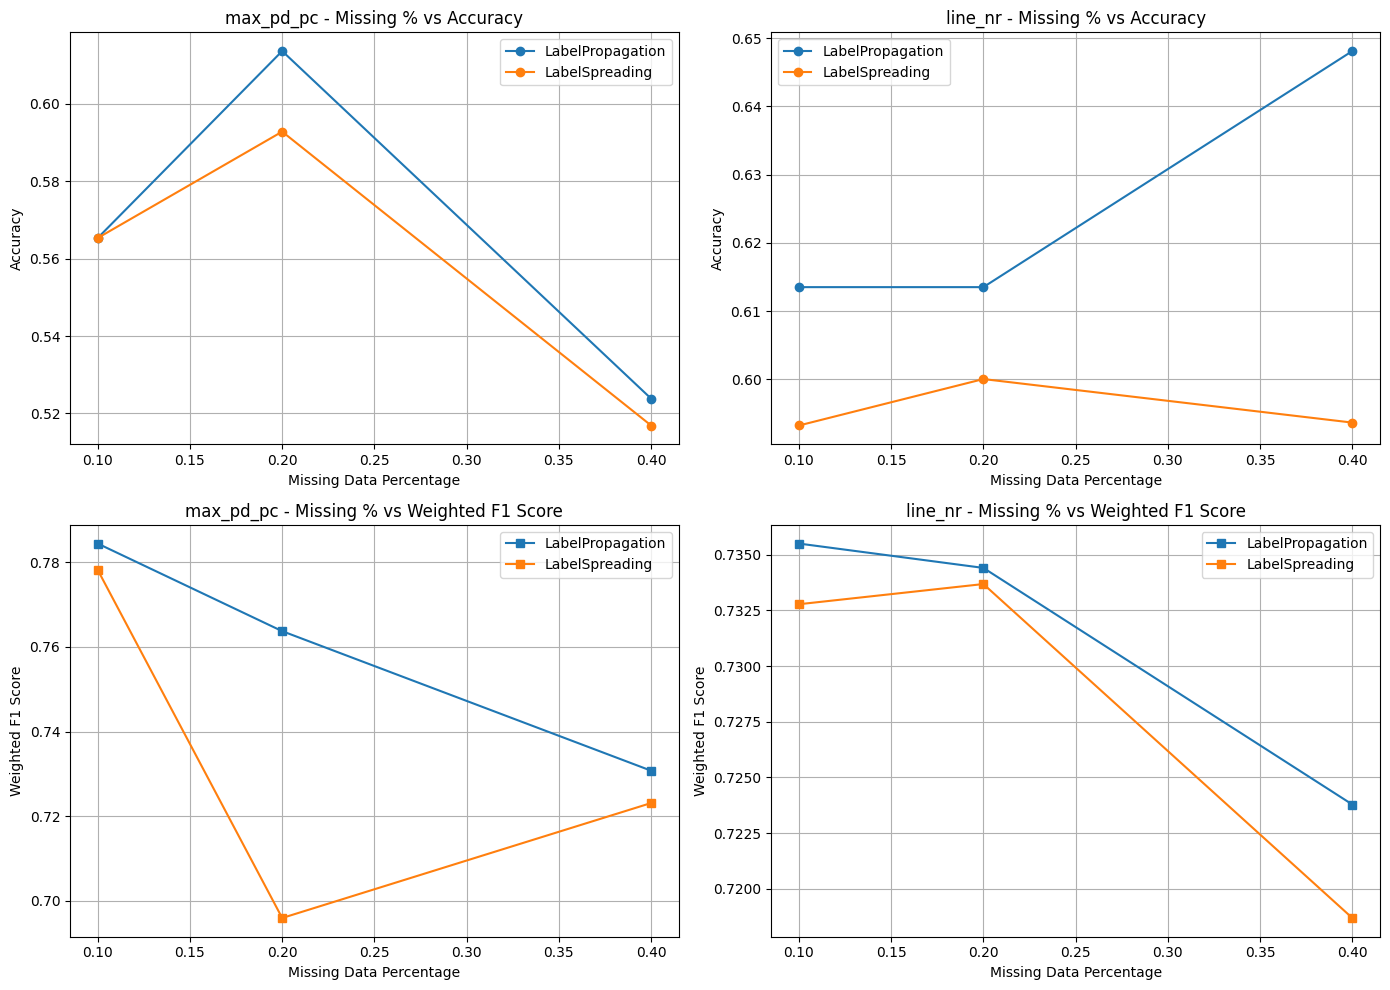

In [30]:
plt.figure(figsize=(14, 10))

for idx, column in enumerate(missing_columns, start=1):
    # Plot Accuracy vs Missing Percentage for this column.
    plt.subplot(2, len(missing_columns), idx)
    for model_type in ['LabelPropagation', 'LabelSpreading']:
        subset = missing_results_df[(missing_results_df['Model'] == model_type) & 
                                    (missing_results_df['Missing Column'] == column)]
        plt.plot(subset['Missing %'], subset['Best Accuracy'], marker='o', label=f"{model_type}")
    plt.title(f'{column} - Missing % vs Accuracy')
    plt.xlabel('Missing Data Percentage')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()
    
    # Plot Weighted F1 Score vs Missing Percentage for this column.
    plt.subplot(2, len(missing_columns), len(missing_columns) + idx)
    for model_type in ['LabelPropagation', 'LabelSpreading']:
        subset = missing_results_df[(missing_results_df['Model'] == model_type) & 
                                    (missing_results_df['Missing Column'] == column)]
        plt.plot(subset['Missing %'], subset['Weighted F1 Score'], marker='s', label=f"{model_type}")
    plt.title(f'{column} - Missing % vs Weighted F1 Score')
    plt.xlabel('Missing Data Percentage')
    plt.ylabel('Weighted F1 Score')
    plt.legend()
    plt.grid()

plt.tight_layout()
plt.show()